In [2]:
from langgraph.graph import MessagesState
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [ ]:
load_dotenv()

# Set your Google API key here
api_key = ""  # Replace with your actual key

if not api_key or api_key == "YOUR_API_KEY_HERE":
    raise ValueError("Please set api_key to your actual GOOGLE_API_KEY")

In [4]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    api_key=api_key,
    streaming=True
)

In [5]:
class ChatState(MessagesState):
    summary: str

In [6]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [7]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [8]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [9]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [10]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

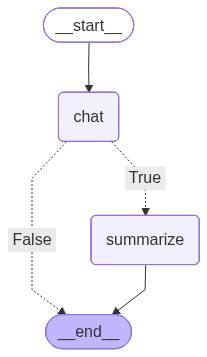

In [11]:
graph

In [13]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57591687-9264-4545-96c4-9c50c48cd053')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum Physics is a branch of physics that deals with the behavior of matter an


In [15]:
run_turn('How is Albert Einstien related?')
show_state()


[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57591687-9264-4545-96c4-9c50c48cd053'), AIMessage(content='Quantum Physics is a branch of physics that deals with the behavior of matter and energy at the atomic and subatomic level. Unlike classical physics, which describes the world at macroscopic scales, quantum physics reveals a reality that is often counter-intuitive and mind-bending.\n\nHere\'s a breakdown of its core ideas, history, and implications:\n\n---\n\n### **What is Quantum Physics?**\n\nAt its heart, quantum physics describes a universe where:\n\n1.  **Quantization:** Energy, momentum, angular momentum, and other physical properties are not continuous but exist in discrete packets called "quanta." For example, light comes in packets called photons, and electrons in an atom can only occupy specific energy levels.\n2.  **Wave-Particle Duality:** Particles (like electrons) can behave like waves, and waves (like light) can behave like p

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='57591687-9264-4545-96c4-9c50c48cd053'), AIMessage(content='Quantum Physics is a branch of physics that deals with the behavior of matter and energy at the atomic and subatomic level. Unlike classical physics, which describes the world at macroscopic scales, quantum physics reveals a reality that is often counter-intuitive and mind-bending.\n\nHere\'s a breakdown of its core ideas, history, and implications:\n\n---\n\n### **What is Quantum Physics?**\n\nAt its heart, quantum physics describes a universe where:\n\n1.  **Quantization:** Energy, momentum, angular momentum, and other physical properties are not continuous but exist in discrete packets called "quanta." For example, light comes in packets called photons, and electrons in an atom can only occupy specific energy levels.\n2.  **Wave-Particle Duality:** Particles (like electrons) can behave like waves, and waves (like light) can behave like p

In [17]:
show_state()


--- STATE ---
summary: 
num_messages: 6
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum Physics is a branch of physics that deals with the behavior of matter an
- HumanMessage : How is Albert Einstien related?
- AIMessage : Albert Einstein's relationship with quantum physics is one of the most fascinati
- HumanMessage : Explain special theory of relativity
- AIMessage : Albert Einstein's **Special Theory of Relativity**, published in 1905, is one of
